In [1]:
!pip install -q langgraph
!pip install -q langchain-groq
!pip install -q langchain-community
!pip install -q ddgs
!pip install wikipedia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.7/551.7 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 43.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py

In [2]:
from typing import TypedDict, Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool

from langchain_groq import ChatGroq
from langchain_community.tools import DuckDuckGoSearchRun

from pydantic import BaseModel

/tmp/ipykernel_10725/3413947232.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [3]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass(
    "Enter GROQ API Key: "
)

Enter GROQ API Key: ··········


After you've set up your `OPENAI_API_KEY` in Colab's Secret Manager, you can retrieve it in your code like this:

Now, you can try running the cells that use the OpenAI API again, and it should pick up the key securely.

In [5]:
# -----------------------------
# LLMkey securely.


# -----------------------------
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

from pydantic import BaseModel

class SearchEvaluation(BaseModel):
    sufficient_results: bool
    reason: str

evaluator_llm = llm.with_structured_output(
    SearchEvaluation
)


# -----------------------------
# TOOLS
# -----------------------------
search_tool = DuckDuckGoSearchRun()

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(top_k_results=3)
)

tools = [search_tool, wikipedia_tool]
llm_with_tools = llm.bind_tools(tools)

In [6]:
class LiteratureState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

    topic: str

    search_results: list

    summaries: list

    gaps: list

    search_attempts: int

    sufficient_results: bool

    final_report: str

In [7]:
def analyze_topic(state):

    topic = state["messages"][-1].content

    return {
        "topic": topic,
        "search_attempts": 0
    }

In [8]:
def search_papers_node(state):
    topic = state["topic"]

    try:
        web_results = search_tool.run(topic)
    except Exception:
        web_results = "Web search unavailable"

    try:
        wiki_results = wikipedia_tool.run(topic)
    except Exception:
        wiki_results = "Wikipedia search unavailable"

    response = llm_with_tools.invoke(
        f"Based on this topic: {topic}, "
        f"what are the key search terms I should look for in literature?"
    )
    return {
        "search_results": [web_results, wiki_results, response.content],
        "search_attempts": state.get("search_attempts", 0) + 1
    }

In [9]:
def evaluate_results(state):

    results = str(
        state["search_results"]
    )

    evaluation = evaluator_llm.invoke(
        f"""
        Determine if enough literature exists
        in the following search results.

        Search Results:
        {results}

        Return:
        - sufficient_results = True if enough information exists
        - sufficient_results = False if information is insufficient
        """
    )

    return {
        "sufficient_results":
            evaluation.sufficient_results
    }

In [10]:
def route_results(state):

    if state["sufficient_results"]:
        return "summarize"

    if state["search_attempts"] >= 2:
        return "summarize"

    return "refine_query"

In [11]:
def refine_query(state):

    topic = state["topic"]

    improved_query = (
        f"latest research papers on {topic}"
    )

    return {
        "topic": improved_query
    }

In [12]:
def summarize_node(state):
    results = str(state["search_results"])
    response = llm.invoke(
        f"""
        Summarize the following literature search results.
        Focus on key findings, main contributions, and important trends.

        Search Results:
        {results}
        """
    )
    return {
        "summaries": [response.content]
    }

In [13]:
def identify_gaps(state):

    response = llm.invoke(
        f"""
        Based on the following literature summary:

        {state['summaries']}

        Identify:
        - Research gaps
        - Limitations
        - Future opportunities
        """
    )

    return {
        "gaps": [response.content]
    }

In [14]:
def final_report_node(state):

    response = llm.invoke(
        f"""
        Create a literature review report.

        Topic:
        {state['topic']}

        Literature Summary:
        {state['summaries']}

        Research Gaps:
        {state['gaps']}

        Format:

        1. Introduction
        2. Key Findings
        3. Research Questions
        4. Research Gaps
        5. Future Directions
        6. Conclusion
        """
    )

    return {
        "final_report": response.content
    }

In [15]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(LiteratureState)

# Nodes
graph.add_node("analyze_topic", analyze_topic)
graph.add_node("search_papers", search_papers_node)
graph.add_node("evaluate", evaluate_results)
graph.add_node("refine_query", refine_query)
graph.add_node("summarize", summarize_node)
graph.add_node("identify_gaps", identify_gaps)
graph.add_node("final_report", final_report_node)

# Edges
graph.add_edge(START, "analyze_topic")

graph.add_edge(
    "analyze_topic",
    "search_papers"
)

graph.add_edge(
    "search_papers",
    "evaluate"
)

graph.add_conditional_edges(
    "evaluate",
    route_results,
    {
        "summarize": "summarize",
        "refine_query": "refine_query"
    }
)

graph.add_edge(
    "refine_query",
    "search_papers"
)

graph.add_edge(
    "summarize",
    "identify_gaps"
)

graph.add_edge(
    "identify_gaps",
    "final_report"
)

graph.add_edge(
    "final_report",
    END
)

In [16]:
# -----------------------------
# PERSISTENCE
# -----------------------------
checkpointer = InMemorySaver()

chatbot = graph.compile(
    checkpointer=checkpointer
)


# -----------------------------
# CONFIG
# -----------------------------
config = {
    "configurable": {
        "thread_id": "student_1"
    }
}

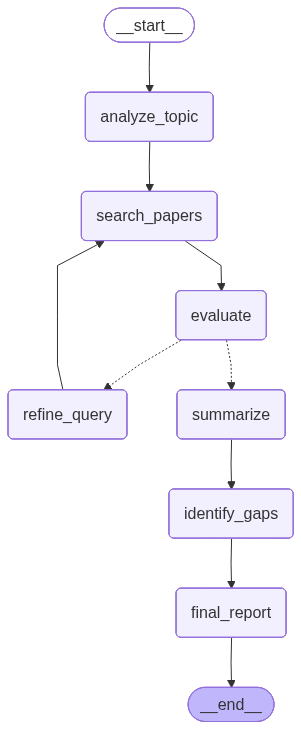

In [17]:
from IPython.display import Image, display

display(
    Image(
        chatbot.get_graph().draw_mermaid_png()
    )
)

In [18]:
while True:

    topic = input("\nEnter Research Topic: ")

    if topic.lower() == "exit":
        break

    result = chatbot.invoke(
        {
            "messages": [
                HumanMessage(content=topic)
            ]
        },
        config=config
    )

    print("\n" + "="*50)
    print(result["final_report"])
    print("="*50)


Enter Research Topic: Transformers in LLM

**Literature Review Report: Transformers in LLM**

**1. Introduction**

The integration of Transformers in Large Language Models (LLMs) has revolutionized the field of natural language processing. The Transformer architecture has become a crucial component of modern LLMs, enabling them to generate and understand human-like language. This literature review aims to summarize the current state of research on Transformers in LLMs, highlighting key findings, research gaps, and future directions.

**2. Key Findings**

The literature search results reveal several key findings:

1. **Transformers and LLMs are closely related but distinct**: LLMs are built on the Transformer architecture, which powers their language generation and understanding capabilities.
2. **Transformer architecture is crucial for modern LLMs**: Understanding the Transformer architecture is essential for making informed decisions about model selection, optimizing prompts, and deb

In [ ]:
print("\nTOPIC")
print(result["topic"])

print("\nSEARCH RESULTS")
print(result["search_results"])

print("\nEVALUATOR OUTPUT")
print(result["sufficient_results"])

print("\nROUTE TAKEN")
print(result.get("route_taken", "Not Available"))

print("\nREFINED QUERY")
print(result.get("refined_query", "No refinement needed"))

print("\nSUMMARY")
print(result["summaries"])

print("\nGAPS")
print(result["gaps"])

print("\nFINAL REPORT")
print(result["final_report"])

print("\nTHREAD ID")
print(config["configurable"]["thread_id"])

print("\nTOPIC HISTORY")
print(result.get("topic_history", []))


TOPIC
what i asked you before

SEARCH RESULTS
['This guide provides a comprehensive overview of academic and research writing for university students, including the different types of research papers and the CARS model for structuring introductions. Master academic writing with 18+ expert Claude prompts for research papers. Improve your data analysis, literature synthesis, and paper structuring for 2026 standards. Now that you have done your research, you are ready to plan your paper. It\'s a good idea to at least think about the order you\'re going to write your paper. It\'ll help the flow of writing as well as greatly help when writing your introductory paragraph. Before planning your paper, go over your professor\'s directions. Some professors are very specific in how they want the paper written. If ... After choosing a topic and gathering background information, add focus with a research question. Explore questions Ask open-ended "how" and "why" questions about your general topic.